# ■ 머신러닝 컴페티션

### 컴페티션의 목표는 ① 이해, ② 풀프로세스 코딩, ③ 설명력을 키우는게 목적입니다.

데이터 출처: https://www.kaggle.com/datasets/gauravtopre/bank-customer-churn-dataset/data

## ■ 공지

※ 모델 성능이 제일 높은 기준으로 채점 X

※ 수업 코드 사용 가능

※ 타 온라인 상 레퍼런스 코드 참고는 가능하나, 통째 복사 금지

※ 학습자 간 상의 절대 금지.

※ 최신 기술 또는 대단한 아이디어 보다. 1. 코딩의 인과성, 2. 설명, 3. 결과 해석에 따른 합당한 인사이트 제안으로 만점이 가능합니다.

</br>

## ■ 평가기준 (총점 90점) ※ 글자 수로 점수 평가 X

1. (15점) 전처리 아이디어 적합성 + 논리 (650자 이내, 주석 서술하기)

2. (20점) EDA를 통한 타당한 해석 (650자 이내, 주석 서술하기)

3. (25점) Feature Selection과 ML 선정 기준 (650자 이내, 주석 서술하기)

4. (25점) SHAP value 사후분석과 인사이트 제안 (650자 이내, 주석 서술하기)

5. (5점 ) validation score 적절하게 출력 (300자 이내, 주석 서술하기)

## ▶ 첫째날, 숙달 Day (감독):

### 18시 까지 코드 완성본 (주석 서술 포함) 제출 (90점) - 시험시작부터 3시간 후 휴식 가능

---

## ▶  둘째날, 포트폴리오화 Day:

### 깃허브에 코드 및 READ ME 이쁘게 정리하여 URL 제출 (10점)

## 레퍼런스 코드 (타이타닉 데이터 버전)

[I 2026-04-08 13:53:59,635] A new study created in memory with name: no-name-5f7cb8f2-a3e6-4f9a-90c8-ddfb56733470
[I 2026-04-08 13:53:59,716] Trial 0 finished with value: 0.7258064516129032 and parameters: {'n_estimators': 121, 'max_depth': 3}. Best is trial 0 with value: 0.7258064516129032.
[I 2026-04-08 13:53:59,887] Trial 1 finished with value: 0.732824427480916 and parameters: {'n_estimators': 205, 'max_depth': 12}. Best is trial 1 with value: 0.732824427480916.
[I 2026-04-08 13:54:00,070] Trial 2 finished with value: 0.6942148760330579 and parameters: {'n_estimators': 222, 'max_depth': 7}. Best is trial 1 with value: 0.732824427480916.
[I 2026-04-08 13:54:00,208] Trial 3 finished with value: 0.7166666666666667 and parameters: {'n_estimators': 181, 'max_depth': 6}. Best is trial 1 with value: 0.732824427480916.
[I 2026-04-08 13:54:00,382] Trial 4 finished with value: 0.7424242424242424 and parameters: {'n_estimators': 200, 'max_depth': 14}. Best is trial 4 with value: 0.74242424242

RF F1: 0.7368421052631579
LR F1: 0.71875
SVM F1: 0.736
KNN F1: 0.7555555555555555


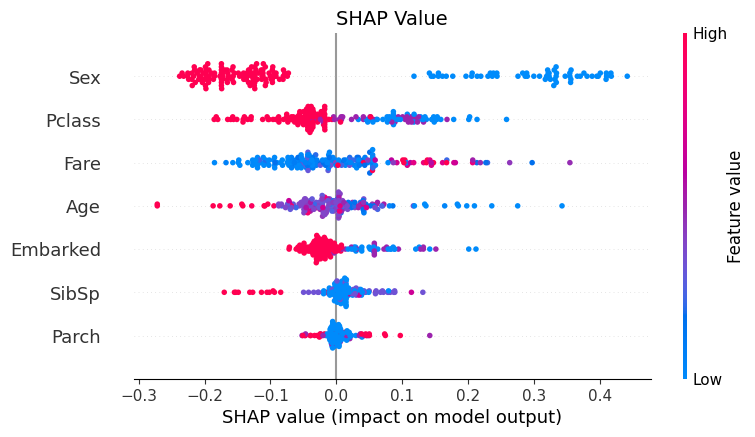

Stacking F1: 0.765625


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import optuna
import shap
import matplotlib.pyplot as plt

# 데이터 로드
df = pd.read_csv('titanic.csv')

# 전처리
# 필요없는 컬럼 제거
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], errors='ignore')

# 결측치 처리
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 범주형 인코딩
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

# ★필독! EDA 제안 해줘야 한다.

# X, y
X = df.drop('Survived', axis=1)
y = df['Survived']

# train valid split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=df["Survived"]
)

# 스케일링
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)


# ★필독! 모델 선정은 pycaret을 이용해서 스코어 잘나오는 모델 4개 고르기


# Optuna : 하이퍼파라미터 리스트는 구글에 각 모델 검색하면 나온다.
#          (예: 랜덤포레스트 optuna 검색)
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
    }
    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_lr(trial):
    params = {
        'C': trial.suggest_float('C', 0.01, 10)
    }
    model = LogisticRegression(**params, max_iter=1000)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_svm(trial):
    params = {
        'C': trial.suggest_float('C', 0.1, 10),
        'kernel': trial.suggest_categorical('kernel', ['linear', 'rbf'])
    }
    model = SVC(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_knn(trial):
    params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 3, 15)
    }
    model = KNeighborsClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

# 각 모델마다 옵튜나로 최적의 하이퍼파라미터 탐색
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=10)

study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(objective_lr, n_trials=10)

study_svm = optuna.create_study(direction='maximize')
study_svm.optimize(objective_svm, n_trials=10)

study_knn = optuna.create_study(direction='maximize')
study_knn.optimize(objective_knn, n_trials=10)

# 옵튜나로 찾은 각각 모델의 하이퍼 파라미터로 각각 모델 옵션 정의
rf = RandomForestClassifier(**study_rf.best_params)
lr = LogisticRegression(**study_lr.best_params, max_iter=1000)
svm = SVC(**study_svm.best_params, probability=True)
knn = KNeighborsClassifier(**study_knn.best_params)

# 모델 학습
rf.fit(X_train, y_train)
lr.fit(X_train, y_train)
svm.fit(X_train, y_train)
knn.fit(X_train, y_train)

# 반복문을 통하여 학습이 완료된 모델 꺼내와서 예측하고 f1스코어 출력
for name, model in [('RF', rf), ('LR', lr), ('SVM', svm), ('KNN', knn)]:
    pred = model.predict(X_valid)
    print(name, "F1:", f1_score(y_valid, pred))

# SHAP - 여기서 랜덤포레스트를 지정해서 사후분석 해보겠다.
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_valid)

# 모델마다 SHAP value 행렬 차원이 다르기 때문에 다르게 설정 (수업에서 강조한 내용)
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]
else:
    shap_values = shap_values

# SHAP  Plot 시각화
shap.summary_plot(
    shap_values, # shape value 반환
    X_valid, # 평가용 데이터로 SHAP value 측정
    feature_names=X.columns, # 컬럼리스트
    plot_type="dot",
    show=False
)
plt.title("SHAP Value", fontsize=14)
plt.show()


# 전방 모델 리스트
est_model_list = [
                      ('rf', rf),
                      ('svm', svm),
                      ('knn', knn)
                  ]


# Stacking 모델 합체
stack = StackingClassifier(
    estimators = est_model_list, # 전방모델
    final_estimator = LogisticRegression() # 후방모델
)

stack.fit(X_train, y_train)

pred = stack.predict(X_valid)
print("Stacking F1:", f1_score(y_valid, pred))

# 전체 코드 하단 작성

## ※ 심플한 코드로는 F1 score가 57정도 나오는 데이터

In [ ]:
import pandas as pd

df = pd.read_csv('Bank Customer Churn Prediction.csv')
df

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [1]:
# 우선 상위 모델 4개를 pycaret으로 먼저 구해보자
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
# 2. 데이터 로드
df = pd.read_csv('Bank Customer Churn Prediction.csv')

# 3. 전처리
# 필요없는 컬럼 제거
df = df.drop(columns=['customer_id'], errors='ignore')

# 범주형 인코딩
le_country = LabelEncoder()
le_gender = LabelEncoder()

df['country'] = le_country.fit_transform(df['country'])
df['gender'] = le_gender.fit_transform(df['gender'])



# split
(train_df), (valid_df) = train_test_split(df, test_size=0.2, random_state=42, stratify=df['churn'])

from pycaret.classification import *

# PyCaret 설정
clf = setup(
              data          = train_df, # 학습할 데이터프레임 (피처랑 정답 같이 있어야함)
              target        = "churn",
              session_id    = 42,
              verbose       = True
            )

# Step 1. 모든 모델 비교 - F1 기준으로 베스트 모델 선택
best_model = compare_models(sort="F1")

# 모델비교 결과 나오면 4개 확인하고 끝.

,Description,Value
0,Session id,42
1,Target,churn
2,Target type,Binary
3,Original data shape,"(8000, 11)"
4,Transformed data shape,"(8000, 11)"
5,Transformed train set shape,"(5600, 11)"
6,Transformed test set shape,"(2400, 11)"
7,Numeric features,10
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ada,Ada Boost Classifier,0.8555,0.8496,0.4804,0.7197,0.5748,0.4921,0.5074,0.0660
lightgbm,Light Gradient Boosting Machine,0.8559,0.8499,0.4768,0.7237,0.5726,0.4907,0.5073,0.1530
gbc,Gradient Boosting Classifier,0.8614,0.8638,0.4549,0.7735,0.5708,0.4951,0.5209,0.1490
catboost,CatBoost Classifier,0.8584,0.8641,0.4637,0.7472,0.5708,0.4918,0.5126,1.1930
rf,Random Forest Classifier,0.8582,0.8443,0.4436,0.7601,0.5593,0.4820,0.5072,0.1540
xgboost,Extreme Gradient Boosting,0.8441,0.8396,0.4786,0.6645,0.5555,0.4641,0.4738,0.0380
et,Extra Trees Classifier,0.8532,0.8424,0.4269,0.7459,0.5418,0.4622,0.4883,0.1070
dt,Decision Tree Classifier,0.7862,0.6777,0.4943,0.4769,0.4849,0.3502,0.3507,0.0140
qda,Quadratic Discriminant Analysis,0.8457,0.8155,0.3243,0.8001,0.4600,0.3887,0.4434,0.0120
lda,Linear Discriminant Analysis,0.8079,0.7611,0.2112,0.5783,0.3086,0.2244,0.2633,0.0120


In [ ]:
# 데이터 로드
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
df = pd.read_csv('Bank Customer Churn Prediction.csv')

# 데이터 전처리 또는 EDA (전처리 기법 왜 그것을 썼는지, 그래프 Draw하고 해석)

# 필요없는 컬럼 제거
df = df.drop(columns=['customer_id'], errors='ignore')

# 범주형 데이터 인코딩
le_country = LabelEncoder()
le_gender = LabelEncoder()

df['country'] = le_country.fit_transform(df['country'])
df['gender'] = le_gender.fit_transform(df['gender'])

from sklearn.model_selection import train_test_split

# X, y
X = df.drop('churn', axis=1)
y = df['churn']

# train valid split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=df["churn"])

# 스케일링

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)


#전처리 주석
# customer_id는 분류에 필요 없기에 컬럼을 제거해었습니다.
# 범주형 데이터가 있어서 country와 gender를 숫자형 데이터로 바꾸어 주었습니다.
# country : France=0, Germany=1, Spain=2
# gender : Female=0, Male=1
# 데이터가 편향된 학습을 하지 않게 하기 위해서 스케일링을 해주었습니다.

In [6]:
df.head(5)
# 전처리가 완료됐는지 5행을 보며 파악했습니다.

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.credit_card.value_counts()
# 신용카드 보유 현황을 파악했습니다.

credit_card
1    7055
0    2945
Name: count, dtype: int64

In [ ]:
aim_df = df[df['credit_card']== 1]
# 신용카드 보유자를 aim_df 변수에 담았습니다.

In [ ]:
aim_df.churn.value_counts()
# 신용카드 보유자중 이탈여부를 확인했습니다.

churn
0    5631
1    1424
Name: count, dtype: int64

In [ ]:
aim_df2 = df[df['credit_card']== 0]
# 신용카드 미보유자를 aim_df2 변수에 담았습니다.

In [ ]:
aim_df2.churn.value_counts()
# 신용카드 미보유자중 이탈여부를 확인했습니다.

churn
0    2332
1     613
Name: count, dtype: int64

<Axes: >

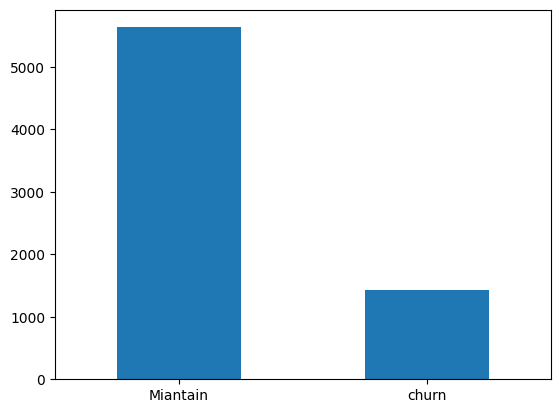

In [ ]:
churn_ratio= aim_df.churn.value_counts()
churn_ratio.index = ['Miantain','churn'] 
churn_ratio.plot(kind = "bar", rot = 0)
# 신용카드 보유자의 이탈여부를 그래프로 그렸습니다.

<Axes: >

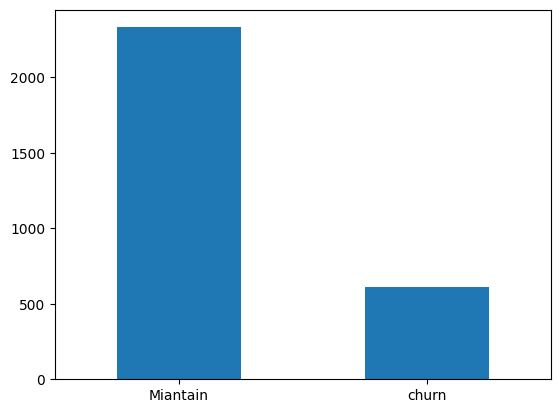

In [ ]:
churn_ratio2= aim_df2.churn.value_counts()
churn_ratio2.index = ['Miantain','churn'] 
churn_ratio2.plot(kind = "bar", rot = 0)
# 신용카드 미보유자의 이탈여부를 그래프로 그렸습니다.

In [ ]:
# eda
# 신용카드 보유 - 유지(5631), 이탈(1424)
# 신용카드 미보유 - 유지(2332), 이탈(613)
# 보유 : 약 0.25의 이탈률
# 미보유 : 약 0.26의 이탈률

# 위의 데이터로 보았을 때 신용카드 보유자와 미보유자의 고객 이탈률을 미미한 것으로 나타났습니다
# 그래서 저는 고객 이탈률은 신용카드의 보유 여부와는 관계가 없다 라는 가설을 가지고 출발했습니다

In [ ]:
# 상위모델 4개 고른 것을, 각 모델 optuna로 최적의 파라미터 찾기

# f1 score가 가장 높은 4개의 모델은 Ada Boost Classifier, Light Gradient Boosting Machine
# Gradient Boosting Classifier, CatBoost Classifier 였습니다.
#그리고 피처 선정은 필요없는 고객id를 제거하고 country컬럼과 gender컬럼을 모두 포함하여 선정했습니다.

import pandas as pd
import numpy as np

from sklearn.metrics import f1_score

from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import optuna

# 각 모델의 추천 optuna 파라미터
def objective_adaboost(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0),
    }
    
    model = AdaBoostClassifier(**params)
    model.fit(X_train, y_train)
    
    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_gb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
    }
    
    model = GradientBoostingClassifier(**params)
    model.fit(X_train, y_train)
    
    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_lgbm(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'num_leaves': trial.suggest_int('num_leaves', 20, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
    }
    
    model = LGBMClassifier(**params)
    model.fit(X_train, y_train)
    
    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_cat(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 200, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
    }
    
    model = CatBoostClassifier(**params, verbose=0)
    model.fit(X_train, y_train)
    
    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

# 각 모델마다 옵튜나로 최적의 하이퍼파라미터 탐색
study_adaboost = optuna.create_study(direction='maximize')
study_adaboost.optimize(objective_adaboost, n_trials=10)

study_gb = optuna.create_study(direction='maximize')
study_gb.optimize(objective_gb, n_trials=10)

study_lgbm = optuna.create_study(direction='maximize')
study_lgbm.optimize(objective_lgbm, n_trials=10)

study_cat = optuna.create_study(direction='maximize')
study_cat.optimize(objective_cat, n_trials=10)

# 옵튜나로 찾은 각각 모델의 하이퍼 파라미터로 각각 모델 옵션 정의
adaboost = AdaBoostClassifier(**study_adaboost.best_params)
gb = GradientBoostingClassifier(**study_gb.best_params)
lgbm = LGBMClassifier(**study_lgbm.best_params)
cat = CatBoostClassifier(**study_cat.best_params, verbose=0)

# 모델 학습
adaboost.fit(X_train, y_train)
gb.fit(X_train, y_train)
lgbm.fit(X_train, y_train)
cat.fit(X_train, y_train)

# 반복문을 통하여 학습이 완료된 모델 꺼내와서 예측하고 f1스코어 출력
for name, model in [('ADABOOST', adaboost), ('GB', gb), ('LGBM', lgbm), ('CAT', cat)]:
    pred = model.predict(X_valid)
    print(name, "F1:", f1_score(y_valid, pred))

[I 2026-04-09 15:33:52,421] A new study created in memory with name: no-name-ee9e2c5c-84f0-44fb-beec-deb54db10ae4
c:\Users\campus4D015\anaconda3\envs\imbk8\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
[I 2026-04-09 15:33:53,088] Trial 0 finished with value: 0.5748148148148148 and parameters: {'n_estimators': 121, 'learning_rate': 0.5770289024569678}. Best is trial 0 with value: 0.5748148148148148.
c:\Users\campus4D015\anaconda3\envs\imbk8\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
[I 2026-04-09 15:33:53,449] Trial 1 finished with value: 0.5714285714285714 and parameters: {'n_estimators': 66, 'learning_rate': 0.708357492735994}. Best is 

[LightGBM] [Info] Number of positive: 1630, number of negative: 6370
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000148 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203750 -> initscore=-1.363019
[LightGBM] [Info] Start training from score -1.363019
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2026-04-09 15:35:01,118] Trial 0 finished with value: 0.5714285714285714 and parameters: {'n_estimators': 335, 'learning_rate': 0.12111613201920214, 'num_leaves': 118, 'max_depth': 6, 'subsample': 0.8256966587898386, 'colsample_bytree': 0.8418947492365418}. Best is trial 0 with value: 0.5714285714285714.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-04-09 15:35:01,238] Trial 1 finished with value: 0.5727136431784108 and parameters: {'n_estimators': 301, 'learning_rate': 0.16213538444774064, 'num_leaves': 30, 'max_depth': 3, 'subsample': 0.6848440707667879, 'colsample_bytree': 0.6762883495891077}. Best is trial 1 with value: 0.5727136431784108.


...

[LightGBM] [Info] Number of positive: 1630, number of negative: 6370
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000246 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203750 -> initscore=-1.363019
[LightGBM] [Info] Start training from score -1.363019
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

[I 2026-04-09 15:35:03,432] Trial 9 finished with value: 0.5778491171749599 and parameters: {'n_estimators': 221, 'learning_rate': 0.01412065286534887, 'num_leaves': 99, 'max_depth': 7, 'subsample': 0.8953771742924335, 'colsample_bytree': 0.646830246550581}. Best is trial 6 with value: 0.5978755690440061.
[I 2026-04-09 15:35:03,432] A new study created in memory with name: no-name-ff6ed0eb-f2b2-4780-abce-72dcd1328b77


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-04-09 15:35:10,591] Trial 0 finished with value: 0.5364431486880467 and parameters: {'iterations': 738, 'learning_rate': 0.08746778493258242, 'depth': 9, 'l2_leaf_reg': 1.5885054521183373, 'subsample': 0.6160934785375236}. Best is trial 0 with value: 0.5364431486880467.
[I 2026-04-09 15:35:11,605] Trial 1 finished with value: 0.5905631659056316 and parameters: {'iterations': 278, 'learning_rate': 0.15303201764831192, 'depth': 4, 'l2_leaf_reg': 1.7510650300760848, 'subsample': 0.6426083127807635}. Best is trial 1 with value: 0.5905631659056316.
[I 2026-04-09 15:35:14,389] Trial 2 finished with value: 0.5672082717872969 and parameters: {'iterations': 429, 'learning_rate': 0.13197344174790693, 'depth': 8, 'l2_leaf_reg': 3.1492850157506793, 'subsample': 0.6709198929376933}. Best is trial 1 with value: 0.5905631659056316.
[I 2026-04-09 15:35:21,531] Trial 3 finished with value: 0.5685425685425686 and parameters: {'iterations': 743, 'learning_rate': 0.1318201881847632, 'depth': 9, 'l

[LightGBM] [Info] Number of positive: 1630, number of negative: 6370
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000254 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203750 -> initscore=-1.363019
[LightGBM] [Info] Start training from score -1.363019
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

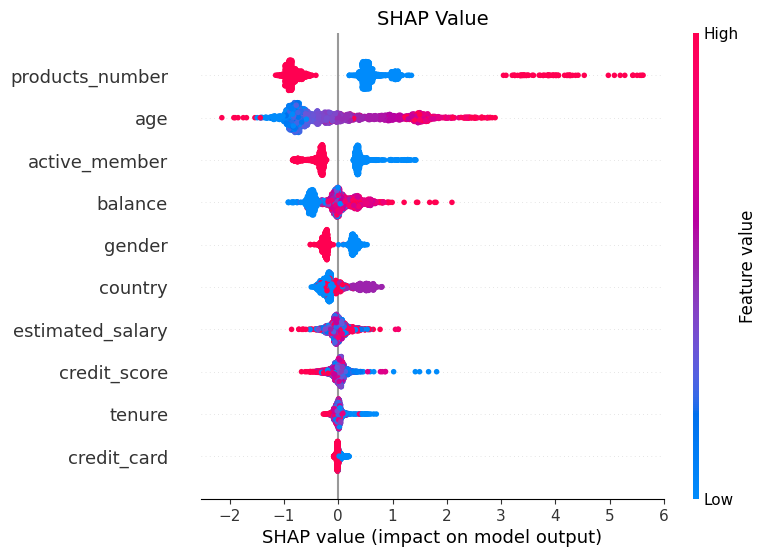

In [ ]:
# 캣부스트 모델 SHAP Value 시각화 하기 
import shap
import matplotlib.pyplot as plt

# SHAP - 여기서 캣부스트를 지정해서 사후분석
explainer = shap.TreeExplainer(cat)
shap_values = explainer.shap_values(X_valid)

# 모델마다 SHAP value 행렬 차원이 다르기 때문에 다르게 설정
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]
else:
    shap_values = shap_values

# SHAP  Plot 시각화
shap.summary_plot(
    shap_values, # shape value 반환
    X_valid, # 평가용 데이터로 SHAP value 측정
    feature_names=X.columns, # 컬럼리스트
    plot_type="dot",
    show=False
)
plt.title("SHAP Value", fontsize=14)
plt.show()



In [ ]:
# 1. 이용 상품 수가 많을수록 고객이 유지되고 적을수록 이탈할 가능성이 높습니다 하지만 너무 많은 상품의 이용은 고객이 이탈할 가능성이 있습니다
# 2. 나이가 어릴수록 유지될 확률이 높고 높읈록 이탈할 확률이 높습니다
# 3. 활성고객이 활성화 될수록 유지 확률이 높고 낮을수록 이탈 확률이 높습니다
# 4. 계좌 잔액이 적을수록 유지 확률이 높고 높을수록 이탈 확률이 높습니다
# 5. 남성일수록 유지확률이 높고 여성일수록 이탈확률이 높습니다
# 6. 프랑스에 사는 사람일수록 유지확률이 높고 스페인에 살수록 이탈확률이 높습니다
# 7. 추정연봉에 대해서는 너무 섞여있어서 파악이 어렵습니다
# 8. 신용점수가 높을수록 유지확률이 높고 낮을수록 이탈확률이 높습니다.
# 9. 이용기간이 높을수록 유지확률이 높고 적을수록 이탈확률이 높습니다
# 10. 신용카드를 보유하지 않은 고객은 이탈할 확률이 있지만 그렇게 큰 차이는 없어보입니다.

# 남성 고객은 유지하는 반면 여성 고객의 이탈률이 매우 높고
# 나이가 많을 수록 이탈률이 높아지는 모습을 보이고 있습니다.
# 고객 이탈을 막기 위해서 노년의 여성들을 위한 상품이 필요해보입니다.
# 은퇴 대책 마련에 도움이 되는 여성 상품을 준비를 하는 것이 좋아보입니다.

In [ ]:
from sklearn.ensemble import StackingClassifier
# 4개 모델을 Stacking(f1_score) 

# 전방 모델 리스트
est_model_list = [
                      ('adaboost', adaboost),
                      ('gb', gb),
                      ('lgbm', lgbm)
                  ]

# Stacking 모델 합체
stack = StackingClassifier(
    estimators = est_model_list, # 전방모델
    final_estimator = CatBoostClassifier() # 후방모델
)

stack.fit(X_train, y_train)
#train 데이터 stack모델로 학습

pred = stack.predict(X_valid)
# X_valid를 통한 예측값 pred 변수에 담기

print("Stacking F1:", f1_score(y_valid, pred))
# 예측값과 정답값을 f1_score를 통해 찍어보기

c:\Users\campus4D015\anaconda3\envs\imbk8\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


[LightGBM] [Info] Number of positive: 1630, number of negative: 6370
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000203 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203750 -> initscore=-1.363019
[LightGBM] [Info] Start training from score -1.363019
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

c:\Users\campus4D015\anaconda3\envs\imbk8\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\campus4D015\anaconda3\envs\imbk8\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\campus4D015\anaconda3\envs\imbk8\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\campus4D015\anaconda3\envs\imbk8\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME

[LightGBM] [Info] Number of positive: 1304, number of negative: 5096
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000115 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 861
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203750 -> initscore=-1.363019
[LightGBM] [Info] Start training from score -1.363019
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

In [ ]:
# adaboost, gb, lgbm을 전방모델로 두고 cat을 후방모델로 둔 스태킹 모델이 학습한
# 예측값과 정답값을 비교해 보았을 때 f1스코어가 약 0.58정도가 나왔습니다.